In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

In [45]:
data = pd.read_csv("dataset.csv")

In [46]:
print(data.head(10))

   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   
5               2                12                  1      17   
6               1                 1                  1      12   
7               1                 9                  4      11   
8               1                 1                  3      10   
9               1                 1                  1      10   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1          

### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset. *Note that three class in this dataset must be merge into two class as: graduate and non-graduate (dropout or enroll)*.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [ ]:
class LogisticRegression:
    def __init__(self, epochs: int, learning_rate: float, threshold: float = 0.5) -> None:
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.losses = []
        self.metrics = []
        self.weights = None 
        self.threshold = threshold

    # Sử dụng hàm sigmoid để chuyển đổi giá trị tuyến tính thành xác suất, sử dụng where để đảm bảo nó không chia cho 0
    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        logits = (1 + np.exp(-z))
        logits = np.where(logits == 0, 10e-5, logits)
        return 1 / logits

    # Sử dụng hàm log loss để tính toán mất mát, thêm một hằng số nhỏ vào log để tránh log(0) không xác định
    def compute_loss(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        return -(y * np.log(y_pred + 10e-5) + (1 - y) * np.log(1 - y_pred + 10e-5)).mean()
    
    def accuracy(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        return (1 - np.abs(y - y_pred)).mean()

    def fit(self, X: np.ndarray, y: np.ndarray, batch_size: int) -> None:
        n_samples = X.shape[0]
        n_features = X.shape[1]
        
        # Khởi tạo trọng số ban đầu là 0
        self.weights = np.zeros(n_features)

        # Bắt đầu quá trình huấn luyện
        pbar = tqdm(range(self.epochs), desc="Đang Training")
        for epoch in pbar:
            indices = np.arange(n_samples)
            np.random.shuffle(indices)

            X_shuffled = X[indices]
            y_shuffled = y[indices]
            # Tối ưu hóa bằng mini-batch gradient descent
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i + batch_size]
                y_batch = y_shuffled[i: i + batch_size]
                
                # Kiểm tra kích thước hiện tại của mini-batch
                current_batch_size = X_batch.shape[0]
                
                # Forward
                linear_model = np.matmul(X_batch, self.weights)
                y_pred = self.sigmoid(linear_model)
                
                # Backward
                mini_batch_grad = (1 / current_batch_size) * np.matmul(X_batch.T, (y_pred - y_batch))
                self.weights -= self.learning_rate * mini_batch_grad
                
            # Evaluating
            y_pred_full = self.sigmoid(np.matmul(X, self.weights))
            loss = self.compute_loss(y, y_pred_full)
            acc = self.accuracy(y, (y_pred_full >= self.threshold).astype(int))

            pbar.set_postfix({
                'Loss': f"{loss:.4f}", 
                'Accuracy': f"{acc:.4f}"
            })

            self.losses.append(loss)
            self.metrics.append(acc)

    def predict(self, X: np.ndarray) -> np.ndarray:
        linear_model = np.matmul(X, self.weights)
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= self.threshold).astype(int)
        

In [48]:
# Gộp nhãn "Dropout" và "Enrolled" thành 0, giữ nguyên "Graduate" là 1
def merge_target(target: str) -> int:
    target_dict = {
        "Dropout": 0,
        "Enrolled": 0,
        "Graduate": 1
    }
    return target_dict[target]

In [49]:
# Dataset sau khi gộp nhãn
data["Target"] = data["Target"].apply(merge_target)
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1


In [50]:
data.shape

(4424, 35)

In [51]:
data.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,0.499322
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,0.500056
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,0.000000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,0.000000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,0.000000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,1.000000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000,1.000000


In [52]:
# Chia tập x_train, y_train, x_test, y_test
x = data.drop(columns = "Target", axis = 0)
y = data["Target"]

test_ratio = 0.2
np.random.seed(42)
indices = np.random.permutation(len(x))

x_new = x.iloc[indices]
y_new = y.iloc[indices]

split_index = int(len(x) * (1 - test_ratio))
x_train = x_new.iloc[:split_index]
y_train = y_new[:split_index]

x_test = x_new.iloc[split_index:]
y_test = y_new.iloc[split_index:]

In [53]:
x_test.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
2766,1,4,1,12,1,3,1,22,27,8,...,0,0,8,8,7,14.414286,0,12.7,3.7,-1.70
4127,1,1,1,3,0,1,1,23,28,6,...,0,0,6,6,6,11.666667,0,10.8,1.4,1.74
1276,1,8,5,14,1,1,1,1,14,10,...,0,0,6,7,5,12.666667,0,11.1,0.6,2.02
1890,1,1,1,2,1,1,1,25,33,5,...,0,0,0,0,0,0.000000,0,11.1,0.6,2.02
624,1,8,4,5,1,1,1,23,27,10,...,0,0,6,8,3,12.666667,0,11.1,0.6,2.02


In [54]:
y_test.head()

2766    1
4127    1
1276    1
1890    1
624     0
Name: Target, dtype: int64

In [55]:
# Tính ma trận tương quan
corr_matrix = data.corr()

<Axes: >

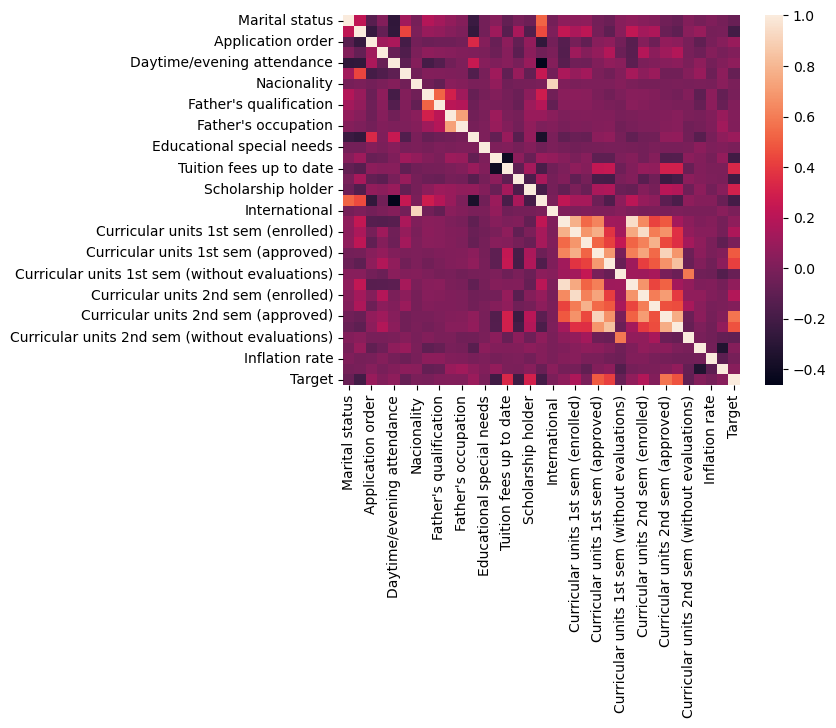

In [56]:
# Vẽ heatmap của ma trận tương quan
sns.heatmap(corr_matrix)

In [31]:
# Hàm tìm các cột có tương quan lớn hơn hoặc bằng ngưỡng cho trước
def correlation(data, threshold):
    corr_col_set = set()
    corr_matrix = data.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                column_name = corr_matrix.columns[j]
                corr_col_set.add(column_name)
                
    return corr_col_set

In [58]:
x_train.shape, x_test.shape

((3539, 34), (885, 34))

In [ ]:
corr_column = correlation(x_train, 0.7)
print(corr_column)

{"Mother's occupation", 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (enrolled)', 'Nacionality', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (credited)', 'Curricular units 2nd sem (approved)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (enrolled)'}


In [60]:
# Loại bỏ các cột có tương quan cao hơn ngưỡng xác định khỏi x_train và x_test
x_train.drop(labels = corr_column, axis = 1, inplace = True)
x_test.drop(labels = corr_column, axis = 1, inplace = True)

/tmp/ipykernel_10052/411119775.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train.drop(labels = corr_column, axis = 1, inplace = True)
/tmp/ipykernel_10052/411119775.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test.drop(labels = corr_column, axis = 1, inplace = True)


In [61]:
x_train.shape, x_test.shape

((3539, 25), (885, 25))

In [62]:
x_train.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Father's occupation,Displaced,...,Age at enrollment,International,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
1255,4,12,1,8,1,1,3,1,6,1,...,30,0,0,0,16,10.000000,0,11.1,0.6,2.02
3458,1,8,1,10,1,1,4,3,2,0,...,18,0,0,0,8,12.142857,0,16.2,0.3,-0.92
3390,1,8,1,16,1,1,23,28,10,0,...,18,0,0,0,7,12.285714,0,16.2,0.3,-0.92
1497,1,8,2,14,1,1,1,1,11,1,...,19,0,0,0,8,13.000000,0,15.5,2.8,-4.06
1536,1,12,1,12,1,1,22,14,9,1,...,27,0,0,0,14,0.000000,0,11.1,0.6,2.02


In [64]:
x_test.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Father's occupation,Displaced,...,Age at enrollment,International,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
2766,1,4,1,12,1,3,22,27,8,1,...,27,0,0,0,8,14.414286,0,12.7,3.7,-1.70
4127,1,1,1,3,0,1,23,28,3,0,...,34,0,0,0,6,11.666667,0,10.8,1.4,1.74
1276,1,8,5,14,1,1,1,14,8,1,...,18,0,0,0,7,12.666667,0,11.1,0.6,2.02
1890,1,1,1,2,1,1,25,33,5,1,...,18,0,0,0,0,0.000000,0,11.1,0.6,2.02
624,1,8,4,5,1,1,23,27,10,0,...,23,0,0,0,8,12.666667,0,11.1,0.6,2.02


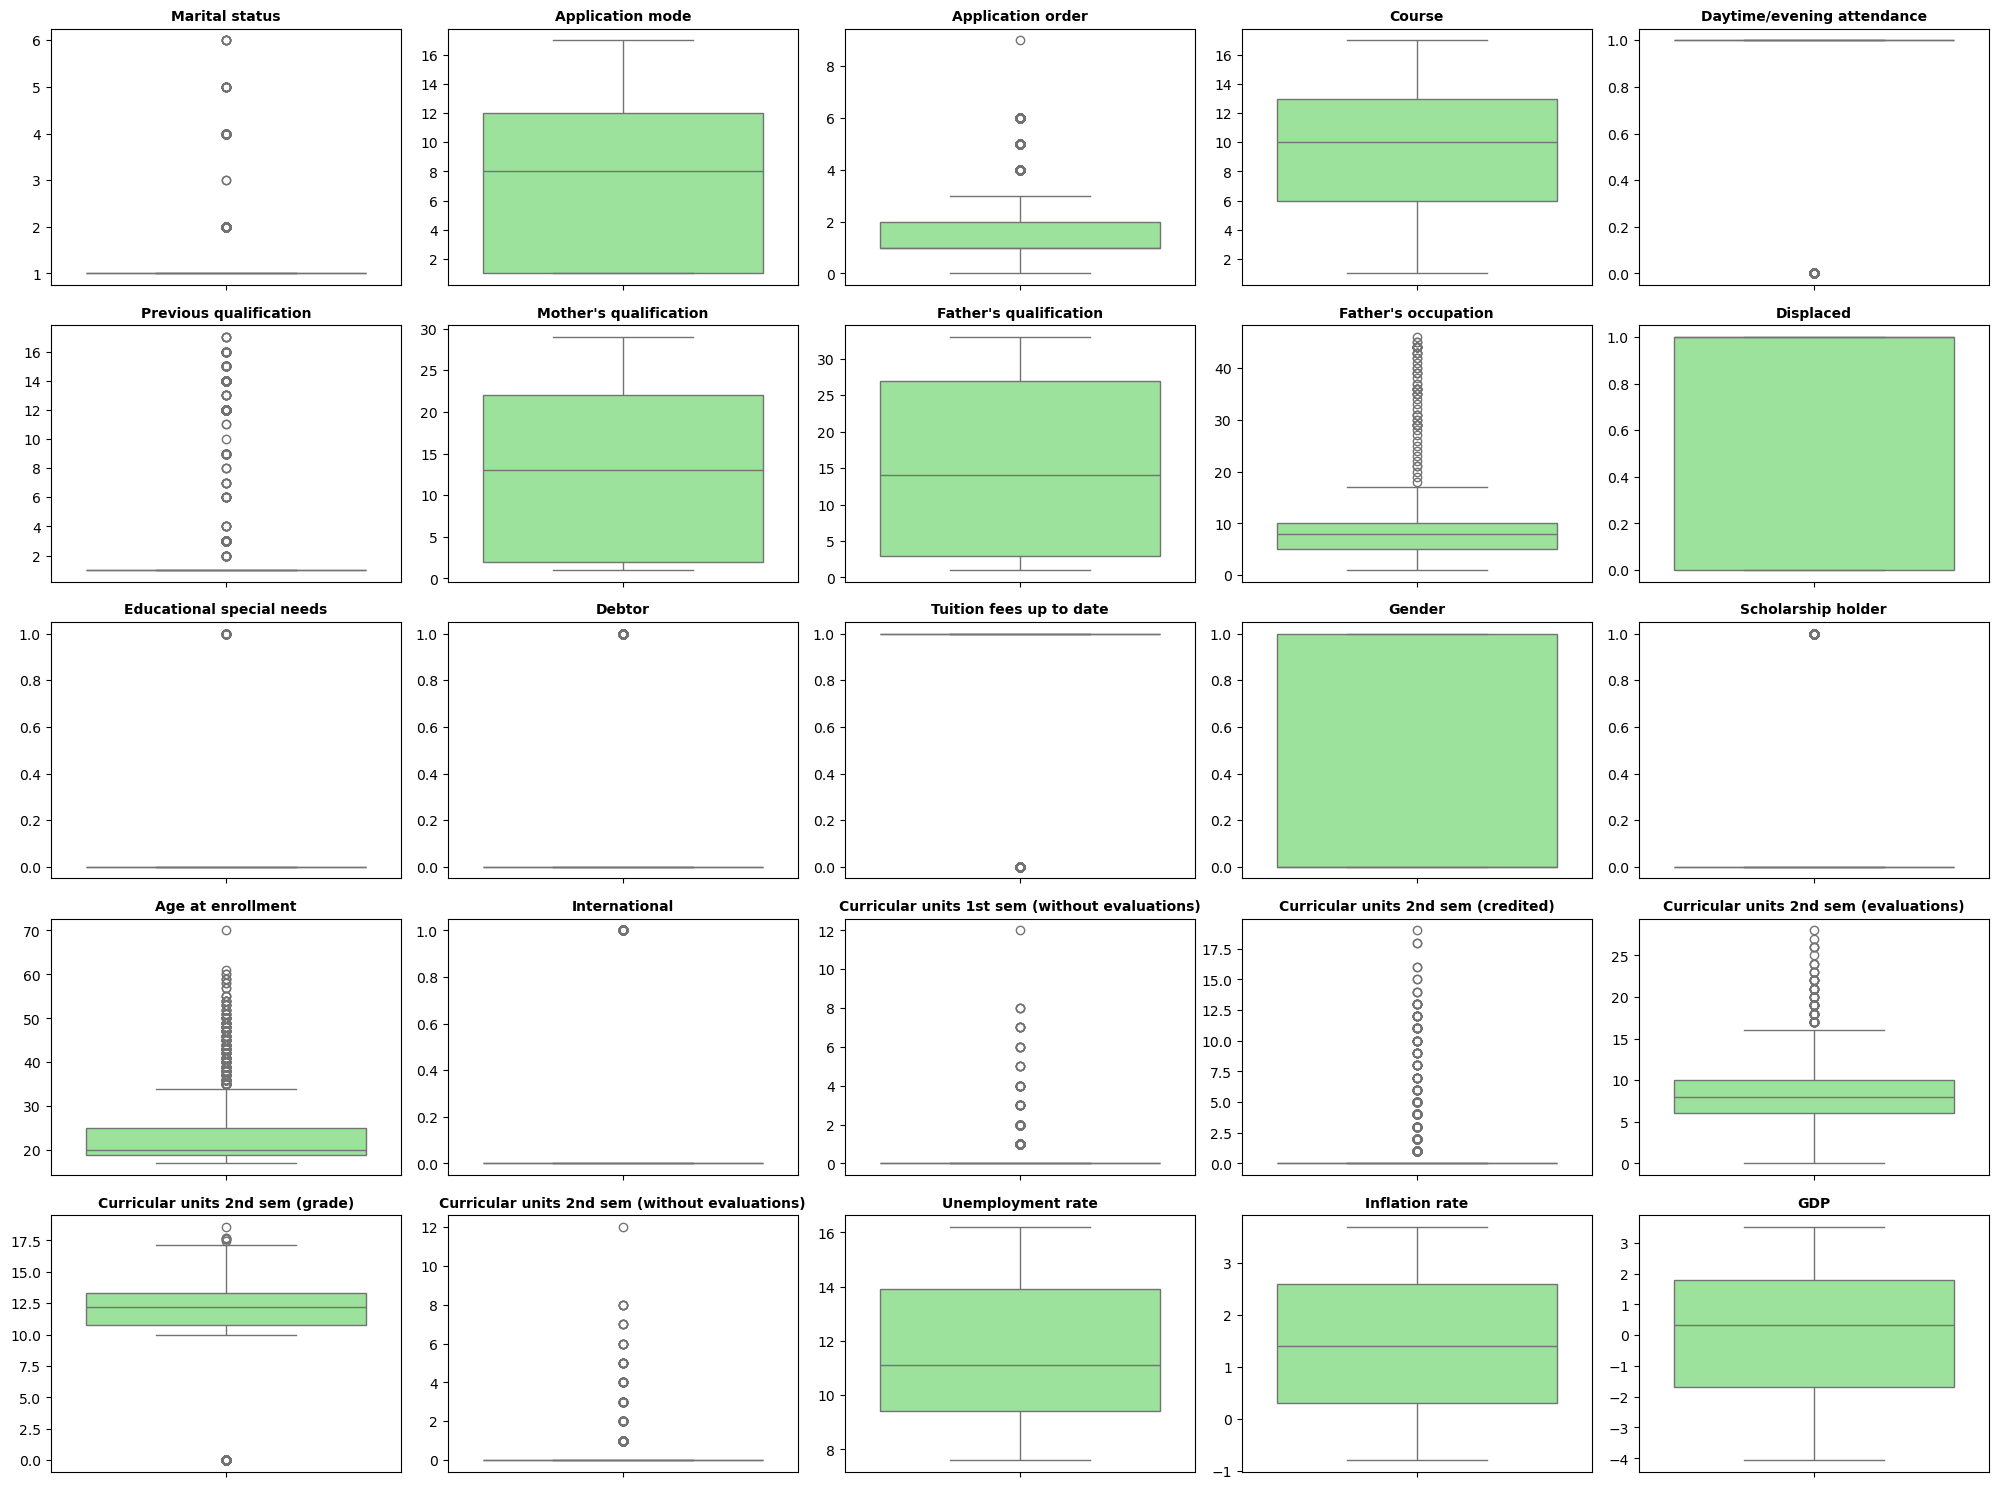

In [ ]:
# Vẽ boxplot cho từng cột của x_train để kiểm tra phân phối dữ liệu và phát hiện outliers
# Lấy danh sách toàn bộ 25 cột của x_train
columns = x_train.columns
n_cols = len(columns)

# Cài đặt lưới 5 cột, tính số hàng tương ứng (5 hàng)
grid_cols = 5
grid_rows = int(n_cols / grid_cols)

# Tạo một "bảng vẽ" siêu to khổng lồ
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(20, 15))
axes = axes.flatten() # Trải phẳng lưới ra để dễ dùng vòng lặp for

# Vẽ boxplot cho từng cột
for i, col in enumerate(columns):
    # Vẽ dạng dọc (y=) cho gọn không gian
    sns.boxplot(y=x_train[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontsize=10, fontweight='bold') # Tên cột làm tiêu đề
    axes[i].set_ylabel('') # Xóa nhãn trục y cho đỡ vướng mắt

# Tự động căn chỉnh khoảng cách giữa các biểu đồ để không bị đè chữ
plt.tight_layout()
plt.show()

In [67]:
# Danh sách các cột cần xóa outlier
target_columns = [
    'Age at enrollment',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (grade)'
]

for col in target_columns:
    # Tính Q1, Q3 và IQR cho từng cột
    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc lấy các dòng hợp lệ
    valid_indices = (x_train[col] >= lower_bound) & (x_train[col] <= upper_bound)
    
    # Ghi đè trực tiếp lên biến x_train và y_train hiện tại
    x_train = x_train[valid_indices]
    y_train = y_train[valid_indices]

In [68]:
x_train.shape, x_test.shape

((2505, 25), (885, 25))

In [69]:
# Chuẩn hóa dữ liệu bằng Z-score cho x_train và x_test
for col in  x_train.columns:
    col_mean = np.mean(x_train[col])
    col_std = np.std(x_train[col])
    
    x_train[col] = (x_train[col] - col_mean) / col_std
    x_test[col] = (x_test[col] - col_mean) / col_std

/tmp/ipykernel_10052/3009214616.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test[col] = (x_test[col] - col_mean) / col_std


In [70]:
x_train.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Father's occupation,Displaced,...,Age at enrollment,International,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
1255,7.240014,1.140792,-0.608072,-0.634930,0.268118,-0.327333,-0.962320,-1.358587,-0.389038,0.814461,...,2.510030,-0.160619,-0.218848,-0.279871,2.983517,-2.015063,-0.197143,-0.146077,-0.450745,0.858956
3458,-0.186782,0.374194,-0.608072,-0.112341,0.268118,-0.327333,-0.851772,-1.177937,-1.171017,-1.227806,...,-0.731710,-0.160619,-0.218848,-0.279871,-0.284750,-0.447103,-0.197143,1.785617,-0.668890,-0.446659
3390,-0.186782,0.374194,-0.608072,1.455426,0.268118,-0.327333,1.248642,1.080184,0.392940,-1.227806,...,-0.731710,-0.160619,-0.218848,-0.279871,-0.693284,-0.342572,-0.197143,1.785617,-0.668890,-0.446659
1497,-0.186782,0.374194,0.106384,0.932837,0.268118,-0.327333,-1.183416,-1.358587,0.588435,0.814461,...,-0.461565,-0.160619,-0.218848,-0.279871,-0.284750,0.180082,-0.197143,1.520482,1.148982,-1.841091
287,-0.186782,1.140792,-0.608072,-1.941403,-3.729707,2.394102,0.806450,-1.358587,-0.975522,-1.227806,...,3.050320,-0.160619,-0.218848,-0.279871,1.349383,-0.917491,-0.197143,-1.471749,1.003552,0.104008


In [71]:
x_test.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Father's occupation,Displaced,...,Age at enrollment,International,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
2766,-0.186782,-0.392403,-0.608072,0.410248,0.268118,0.216954,1.138094,0.989859,0.001951,0.814461,...,1.699595,-0.160619,-0.218848,-0.279871,-0.284750,1.214936,-0.197143,0.459944,1.803416,-0.793047
4127,-0.186782,-0.967351,-0.608072,-1.941403,-3.729707,-0.327333,1.248642,1.080184,-0.975522,-1.227806,...,3.590610,-0.160619,-0.218848,-0.279871,-1.101817,-0.795538,-0.197143,-0.259706,0.130974,0.734611
1276,-0.186782,0.374194,2.249752,0.932837,0.268118,-0.327333,-1.183416,-0.184364,0.001951,0.814461,...,-0.731710,-0.160619,-0.218848,-0.279871,-0.693284,-0.063823,-0.197143,-0.146077,-0.450745,0.858956
1890,-0.186782,-0.967351,-0.608072,-2.202697,0.268118,-0.327333,1.469738,1.531809,-0.584533,0.814461,...,-0.731710,-0.160619,-0.218848,-0.279871,-3.553018,-9.332214,-0.197143,-0.146077,-0.450745,0.858956
624,-0.186782,0.374194,1.535296,-1.418814,0.268118,-0.327333,1.248642,0.989859,0.392940,-1.227806,...,0.619015,-0.160619,-0.218848,-0.279871,-0.284750,-0.063823,-0.197143,-0.146077,-0.450745,0.858956


In [ ]:
# Kiểm tra xem y_train có bị mất cân bằng không sau khi loại bỏ outliers
y_train.value_counts()

Target
1    1527
0     978
Name: count, dtype: int64

In [140]:
model_LR = LogisticRegression(epochs = 560, learning_rate = 0.055)
model_LR.fit(x_train.to_numpy(), y_train.to_numpy(), batch_size = 16)

Đang Training: 100%|██████████| 560/560 [00:00<00:00, 613.25it/s, Loss=0.5090, Accuracy=0.7573]


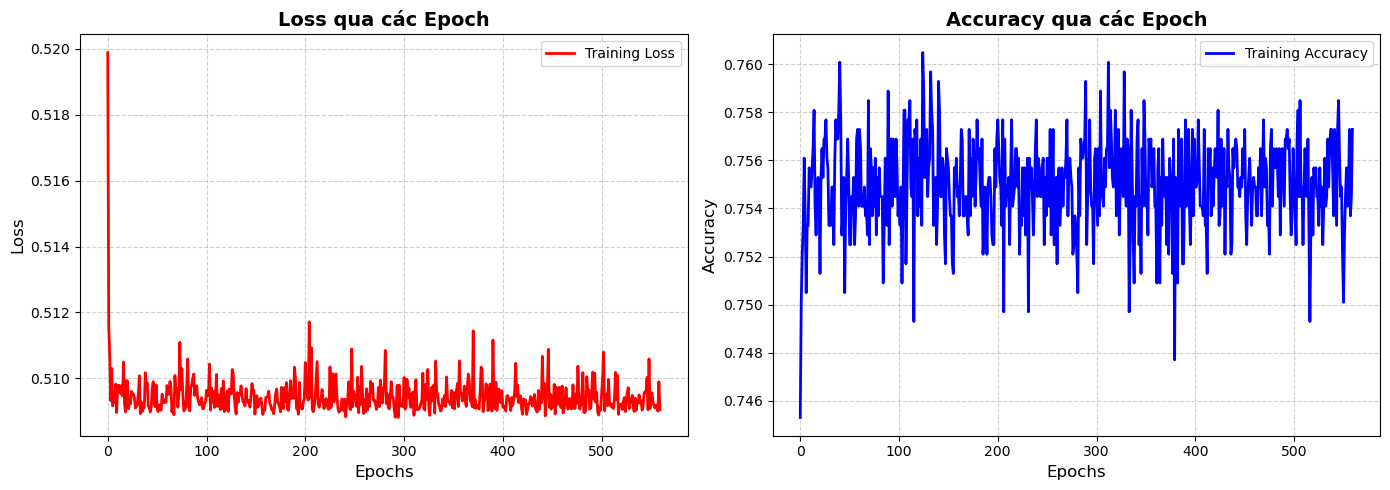

In [141]:
import matplotlib.pyplot as plt

# Tạo một khung để chứa 2 biểu đồ cạnh nhau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Vẽ biểu đồ Loss
ax1.plot(model_LR.losses, color='red', linewidth=2, label='Training Loss')
ax1.set_title('Loss qua các Epoch', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Vẽ biểu đồ Accuracy 
ax2.plot(model_LR.metrics, color='blue', linewidth=2, label='Training Accuracy')
ax2.set_title('Accuracy qua các Epoch', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

**Report cho Assignment 1:**
- Đây là dataset có 3 nhãn nên nó được gộp lại thành 2 nhóm là 0 cho "Dropout", "Enrolled" và 1 cho "Graduate" để phù hợp với bài toán phân loại nhị phân sử dụng mô hình Logistic Regression.
- Code from scratch mô hình Logistic Regression bằng numpy. Ngoài ra trong mô hình mà tôi tự xây dựng thì có khai báo thêm biến threshold để tùy chọn thay đổi ngưỡng khi cần.
- Tự phân chia bộ train và bộ test mà không dùng đến thư viện của scikit-learn
- Áp dụng các phuơng pháp tiền xử lý như xóa các cột có sự tương quan lớn hơn hoặc bằng 0.7, vẽ biểu đồ để xác định các cột nào có chứa outliers sau đó xóa bỏ các dòng có chứa outliers, chuẩn hóa dữ liệu bằng phương pháp Z-score với mean = 0 và std = 1.
- Có 1 lưu ý là khi sử dụng Z-score thì bắt buộc chuẩn hóa bộ test trên thông tin dữ liệu (mean, std) của bộ train để không xảy ra hiện tượng data leakage.
- Thực hiện huấn luyện mô hình và các siêu tham số truyền vào là epoch = 560, learning_rate = 0.055.
- KẾT QUẢ: Loss=0.5090, Accuracy=0.7573 => Nhìn chung mô hình tự xây dựng và qua các bước tiền xử lý thì cho ra kết quả không tệ.
- Biểu đồ của Loss và Accuracy qua các epoch cho thấy 2 giá trị này dao động liên tục trong các khoảng nhỏ. Điều này thể hiện mô hình học tốt và đã hội tụ từ những epoch đầu tiên.

### Assignment 2 (4 scores):

- Use Numpy only to construct the Sofmax Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [21]:
class SoftmaxRegression:
    def __init__(self, epochs: int, learning_rate: float) -> None:
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.losses = []
        self.metrics = []
        self.weights = None 

    def softmax(self, z: np.ndarray) -> np.ndarray:
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Trừ max để tránh overflow
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def compute_loss(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        m = y.shape[0]
        log_likelihood = -np.log(y_pred[range(m), y] + 10e-5)  # Thêm hằng số nhỏ để tránh log(0)
        return np.sum(log_likelihood) / m
    
    def accuracy(self, y: np.ndarray, y_pred: np.ndarray) -> float:
        return (y == y_pred).mean()

    def fit(self, X: np.ndarray, y: np.ndarray, batch_size: int) -> None:
        n_samples = X.shape[0]
        n_features = X.shape[1]
        n_classes = len(np.unique(y))
        
        # Khởi tạo trọng số ban đầu là 0
        self.weights = np.zeros((n_features, n_classes))

        # Bắt đầu quá trình huấn luyện
        pbar = tqdm(range(self.epochs), desc="Đang Training")
        for epoch in pbar:
            indices = np.arange(n_samples)
            np.random.shuffle(indices)

            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i: i + batch_size]
                y_batch = y_shuffled[i: i + batch_size]
                
                current_batch_size = X_batch.shape[0]
                
                # Forward
                linear_model = np.matmul(X_batch, self.weights)
                y_pred = self.softmax(linear_model)
                
                # Backward
                y_one_hot = np.zeros_like(y_pred)
                y_one_hot[np.arange(current_batch_size), y_batch] = 1
                mini_batch_grad = (1 / current_batch_size) * np.matmul(X_batch.T, (y_pred - y_one_hot))
                self.weights -= self.learning_rate * mini_batch_grad

            # Evaluating
            linear_model_full = np.matmul(X, self.weights)
            y_pred_full = self.softmax(linear_model_full)
            loss = self.compute_loss(y, y_pred_full)
            acc = self.accuracy(y, np.argmax(y_pred_full, axis=1))
            self.losses.append(loss)
            self.metrics.append(acc)

            pbar.set_postfix({
                'Loss': f"{loss:.4f}", 
                'Accuracy': f"{acc:.4f}"
            })

    def predict(self, X: np.ndarray) -> np.ndarray:
        linear_model = np.matmul(X, self.weights)
        y_pred = self.softmax(linear_model)
        return np.argmax(y_pred, axis=1)

In [64]:
data_2 = pd.read_csv("dataset.csv")

In [65]:
print(data_2.head(10))

   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   
5               2                12                  1      17   
6               1                 1                  1      12   
7               1                 9                  4      11   
8               1                 1                  3      10   
9               1                 1                  1      10   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1          

In [66]:
def convert_target(target: str) -> int:
    target_dict = {
        "Dropout": 0,
        "Enrolled": 1,
        "Graduate": 2   
    }
    return target_dict[target]

In [67]:
data_2["Target"] = data_2["Target"].apply(convert_target)
data_2.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2


In [68]:
# Chia tập x_train, y_train, x_test, y_test
x = data_2.drop(columns = "Target", axis = 0)
y = data_2["Target"]

test_ratio = 0.2
np.random.seed(42)
indices = np.random.permutation(len(x))

x_new_2 = x.iloc[indices]
y_new_2 = y.iloc[indices]

split_index = int(len(x) * (1 - test_ratio))
x_train_2 = x_new_2.iloc[:split_index]
y_train_2 = y_new_2[:split_index]

x_test_2 = x_new_2.iloc[split_index:]
y_test_2 = y_new_2.iloc[split_index:]

In [69]:
corr_column_2 = correlation(x_train_2, 0.8)
print(corr_column_2)

{'Curricular units 1st sem (approved)', 'Curricular units 1st sem (credited)', 'Nacionality', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (enrolled)'}


In [70]:
# Loại bỏ các cột có tương quan cao hơn ngưỡng xác định khỏi x_train và x_test
x_train_2.drop(labels = corr_column_2, axis = 1, inplace = True)
x_test_2.drop(labels = corr_column_2, axis = 1, inplace = True)

/tmp/ipykernel_15092/3000039158.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_train_2.drop(labels = corr_column_2, axis = 1, inplace = True)
/tmp/ipykernel_15092/3000039158.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_2.drop(labels = corr_column_2, axis = 1, inplace = True)


In [71]:
x_train_2.shape, x_test_2.shape

((3539, 29), (885, 29))

In [72]:
# Danh sách các cột cần xóa outlier
target_columns = [
    'Age at enrollment',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (grade)'
]

for col in target_columns:
    # Tính Q1, Q3 và IQR cho từng cột
    Q1 = x_train_2[col].quantile(0.25)
    Q3 = x_train_2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc lấy các dòng hợp lệ
    valid_indices = (x_train_2[col] >= lower_bound) & (x_train_2[col] <= upper_bound)
    
    # Ghi đè trực tiếp lên biến x_train_2 và y_train_2 hiện tại
    x_train_2 = x_train_2[valid_indices]
    y_train_2 = y_train_2[valid_indices]

In [73]:
# Chuẩn hóa dữ liệu bằng Z-score cho x_train và x_test
for col in  x_train_2.columns:
    col_mean = np.mean(x_train_2[col])
    col_std = np.std(x_train_2[col])
    
    x_train_2[col] = (x_train_2[col] - col_mean) / col_std
    x_test_2[col] = (x_test_2[col] - col_mean) / col_std

/tmp/ipykernel_15092/2281053702.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_2[col] = (x_test_2[col] - col_mean) / col_std


In [74]:
x_train_2.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
1255,7.240014,1.140792,-0.608072,-0.634930,0.268118,-0.327333,-0.962320,-1.358587,-0.324342,-0.389038,...,-0.218848,-0.279871,-0.323115,2.983517,-2.186203,-2.015063,-0.197143,-0.146077,-0.450745,0.858956
3458,-0.186782,0.374194,-0.608072,-0.112341,0.268118,-0.327333,-0.851772,-1.177937,-1.290712,-1.171017,...,-0.218848,-0.279871,-0.323115,-0.284750,0.291824,-0.447103,-0.197143,1.785617,-0.668890,-0.446659
3390,-0.186782,0.374194,-0.608072,1.455426,0.268118,-0.327333,1.248642,1.080184,0.642029,0.392940,...,-0.218848,-0.279871,0.340874,-0.693284,0.787429,-0.342572,-0.197143,1.785617,-0.668890,-0.446659
1497,-0.186782,0.374194,0.106384,0.932837,0.268118,-0.327333,-1.183416,-1.358587,-0.565934,0.588435,...,-0.218848,-0.279871,-0.323115,-0.284750,-0.203782,0.180082,-0.197143,1.520482,1.148982,-1.841091
287,-0.186782,1.140792,-0.608072,-1.941403,-3.729707,2.394102,0.806450,-1.358587,1.125214,-0.975522,...,-0.218848,-0.279871,-0.323115,1.349383,-0.699387,-0.917491,-0.197143,-1.471749,1.003552,0.104008


In [75]:
x_test_2.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
2766,-0.186782,-0.392403,-0.608072,0.410248,0.268118,0.216954,1.138094,0.989859,0.158843,0.001951,...,-0.218848,-0.279871,1.004863,-0.284750,0.787429,1.214936,-0.197143,0.459944,1.803416,-0.793047
4127,-0.186782,-0.967351,-0.608072,-1.941403,-3.729707,-0.327333,1.248642,1.080184,-0.324342,-0.975522,...,-0.218848,-0.279871,-0.323115,-1.101817,0.291824,-0.795538,-0.197143,-0.259706,0.130974,0.734611
1276,-0.186782,0.374194,2.249752,0.932837,0.268118,-0.327333,-1.183416,-0.184364,0.642029,0.001951,...,-0.218848,-0.279871,-0.323115,-0.693284,-0.203782,-0.063823,-0.197143,-0.146077,-0.450745,0.858956
1890,-0.186782,-0.967351,-0.608072,-2.202697,0.268118,-0.327333,1.469738,1.531809,-0.565934,-0.584533,...,-0.218848,-0.279871,-4.307048,-3.553018,-2.681809,-9.332214,-0.197143,-0.146077,-0.450745,0.858956
624,-0.186782,0.374194,1.535296,-1.418814,0.268118,-0.327333,1.248642,0.989859,0.642029,0.392940,...,-0.218848,-0.279871,-0.323115,-0.284750,-1.194993,-0.063823,-0.197143,-0.146077,-0.450745,0.858956


In [76]:
y_train_2.value_counts()

Target
2    1527
1     527
0     451
Name: count, dtype: int64

In [77]:
model_SR = SoftmaxRegression(epochs = 1000, learning_rate = 0.01)
model_SR.fit(x_train_2.to_numpy(), y_train_2.to_numpy(), batch_size = 32)

Đang Training: 100%|██████████| 1000/1000 [00:01<00:00, 527.60it/s, Loss=0.7055, Accuracy=0.7202]


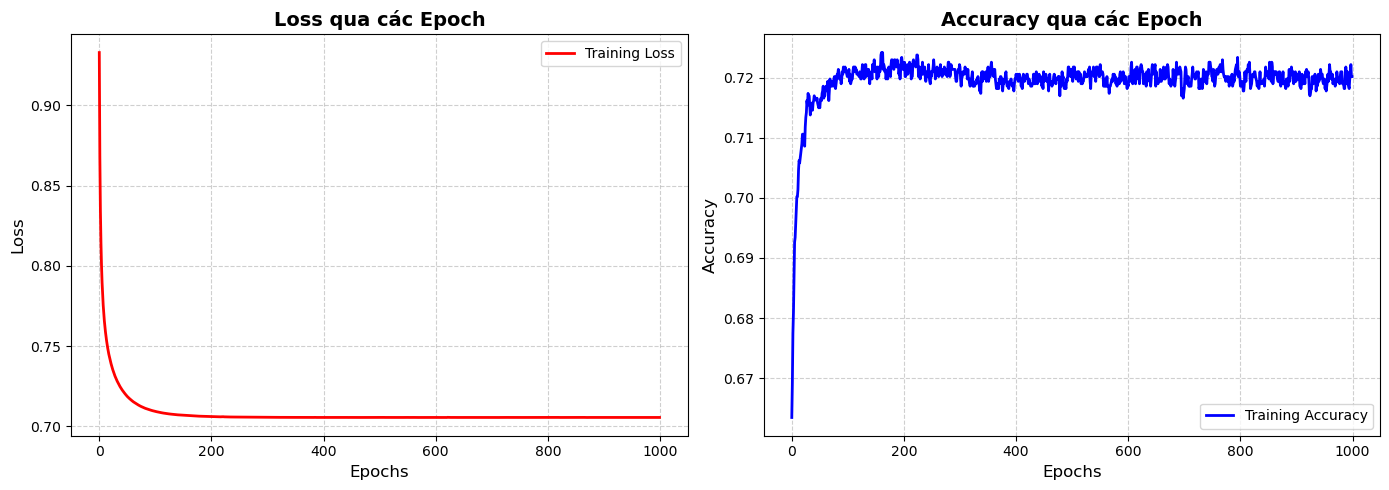

In [78]:
# Tạo một khung để chứa 2 biểu đồ cạnh nhau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Vẽ biểu đồ Loss
ax1.plot(model_SR.losses, color='red', linewidth=2, label='Training Loss')
ax1.set_title('Loss qua các Epoch', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Vẽ biểu đồ Accuracy 
ax2.plot(model_SR.metrics, color='blue', linewidth=2, label='Training Accuracy')
ax2.set_title('Accuracy qua các Epoch', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

**REPORT ASSIGNMENT 2:**
- Ở Assignment 2 này tôi cũng thưc hiện các bước tiền xử lý như Assignment 1, tuy nhiên ở bước loại bỏ các cột có tương quan cao thì tôi đã điều chỉnh lên con số là 0.8 thay vì 0.7 như Assignment 1. Khi chạy thực nghiệm mô hình thì tôi đã phát hiện được rằng với threshold là 0.8 thì mô hình cho ra kết quả Accuracy cao hơn so với threshold là 0.7 khi nó không thể cho ra được Accuracy cao hơn được 70%
- Ở phần xây dựng mô hình tôi cũng xây dựng các hàm cần thiết của mô hình Softmax Regression như compute_loss, predict, fit, accuracy và softmax. Cụ thể thì có thể quan sát trực tiếp trên mô hình.
- KẾT QUẢ: Loss=0.7055, Accuracy=0.7202. Sau một thời gian chạy thực nghiệm và cải tiến thì kết quả tôi tối ưu cao nhất được như thế này.
- Biểu đổ được trực quan hóa cũng tương tự như biểu đồ của mô hình Logistic Regression.

### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

**A. LOGISTIC REGRESSION**

In [ ]:
model_LR_sklean = LogisticRegression()
model.LR_sklean.fit(x_train.to_numpy(), y_train.to_numpy())